# Futures Backtesting with Contract Specifications

**Docker image**: `ml4t`

This notebook introduces futures-specific backtesting mechanics using the
**ml4t-backtest** engine. It is an in-sample teaching simulation, not a sealed
holdout estimate or a deployable roll implementation.

| Aspect | Equities | Futures |
|--------|----------|---------|
| **P&L Formula** | (exit - entry) × qty | (exit - entry) × qty × **multiplier** |
| **Costs** | % of trade value | **$ per contract** (fixed) |
| **Sessions** | Market hours (9:30-4 ET) | **Overnight sessions** (e.g., 5 PM CT) |
| **Long-Short** | Short selling requires borrowing | No stock loan; both legs require margin |
| **Position Sizing** | Shares × price | Contracts × price × **multiplier** |

**Learning Objectives:**
1. Define `ContractSpec` and understand how multipliers convert points to dollars
2. Size positions correctly using notional value (price × multiplier)
3. Implement a long-short momentum strategy (natural for futures)
4. Compare per-contract vs percentage-based costs
5. Analyze sector attribution across diversified asset classes

**Book Reference:** Chapter 16, Sections 16.2-16.3 - trading protocol and
event-driven validation.

**Prerequisites:**
- Ch2 NB 04 ([`04_cme_futures_eda`](../02_financial_data_universe/04_cme_futures_eda.ipynb)): CME data structure
- Ch2 NB 05 ([`05_futures_session_aggregation`](../02_financial_data_universe/05_futures_session_aggregation.ipynb)): Session boundaries (4 PM CT)
- Ch2 NB 06 ([`06_futures_continuous`](../02_financial_data_universe/06_futures_continuous.ipynb)): Continuous contract construction
- Ch16 NB 01-03: Backtesting first principles and ml4t-backtest basics

## Setup

In [1]:
"""Futures backtesting with multiplier-aware simulation in ml4t-backtest."""

import warnings
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

# Data loading
# ml4t-backtest imports
from ml4t.backtest import (
    AssetClass,
    BacktestConfig,
    ContractSpec,
    DataFeed,
    Engine,
    ExecutionMode,
    OrderSide,
    Strategy,
)
from ml4t.backtest.config import CommissionType, SlippageType

from data import load_cme_futures
from utils.paths import REPO_ROOT
from utils.style import COLOR_CYCLER, COLORS

In [2]:
# Production defaults - Papermill injects overrides after this cell
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 10_000_000
LOOKBACK = 63  # ~3 months momentum lookback
REBALANCE_EVERY = 21  # ~monthly rebalance (trading days)
LONG_N = 2  # Long top 2 by momentum
SHORT_N = 2  # Short bottom 2 by momentum
RUN_FULL_UNIVERSE = True

In [3]:
def format_usd(value: float) -> str:
    """Format signed dollar values with the sign before the currency symbol."""
    sign = "-" if value < 0 else ""
    return f"{sign}${abs(value):,.0f}"

In [4]:
# Six demo products - one per sector
PRODUCTS = ["ES", "CL", "GC", "ZN", "6E", "ZC"]

Contract specifications are current static metadata. The margin percentages in the YAML are
anchored to 2025-12-31 prices and a 2026-05-16 CME rates snapshot; the simulation applies them
across 2018-2023 and does not model historical specification or margin changes.

In [5]:
SPECS_PATH = REPO_ROOT / "data" / "futures" / "market" / "futures_specs.yaml"


def load_contract_specs_from_yaml(yaml_path: Path) -> dict[str, ContractSpec]:
    """Load point-value multipliers and margin percentages from the futures specification."""
    with yaml_path.open() as file:
        raw = yaml.safe_load(file)

    specs = {}
    for symbol, info in raw["products"].items():
        initial_margin = info.get("initial_margin_pct")
        maintenance_margin = info.get("maintenance_margin_pct")
        assert (initial_margin is None) == (maintenance_margin is None)
        margin_pct = (initial_margin, maintenance_margin) if initial_margin is not None else None
        specs[symbol] = ContractSpec(
            symbol=symbol,
            asset_class=AssetClass.FUTURE,
            multiplier=info["tick_value"] / info["tick_size"],
            tick_size=info["tick_size"],
            margin_pct=margin_pct,
        )
    return specs


FULL_SPECS = load_contract_specs_from_yaml(SPECS_PATH)
DEMO_SPECS = {product: FULL_SPECS[product] for product in PRODUCTS}

## 1. Load CME Futures Data

We load session-aligned daily bars via `load_cme_futures()`. These bars use
**4 PM CT session boundaries** (not midnight UTC) - see Ch2 NB 05 for the
aggregation methodology that converts hourly Databento bars to daily sessions.

In [6]:
cme_data = load_cme_futures(products=PRODUCTS, tenors=[0], start_date=START_DATE, end_date=END_DATE)

available_products = sorted(cme_data["product"].unique().to_list())
missing_products = [product for product in PRODUCTS if product not in available_products]
if missing_products:
    print(f"Unavailable in current data slice: {missing_products}")
PRODUCTS = [product for product in PRODUCTS if product in available_products]
if len(PRODUCTS) < LONG_N + SHORT_N:
    raise ValueError(
        "Need at least LONG_N + SHORT_N products after filtering for available futures data."
    )

print(f"Loaded {len(cme_data):,} daily bars for {cme_data['product'].n_unique()} products")
print(f"Date range: {cme_data['session_date'].min()} to {cme_data['session_date'].max()}")
print(f"Products: {sorted(cme_data['product'].unique().to_list())}")

Loaded 9,251 daily bars for 6 products
Date range: 2018-01-02 to 2023-12-29
Products: ['6E', 'CL', 'ES', 'GC', 'ZC', 'ZN']


Sample of the loaded session-daily bars (first six rows):

In [7]:
cme_data.head(6)

session_date,product,tenor,adj_open,adj_high,adj_low,adj_close,raw_open,raw_high,raw_low,raw_close,cum_ratio,volume,bar_count,session_start,session_end
date,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u64,u32,"datetime[ns, UTC]","datetime[ns, UTC]"
2018-01-02,"""6E""",0,1.402626,1.410179,1.401057,1.407274,1.207,1.2135,1.20565,1.211,1.162076,188647,23,2018-01-01 23:00:00 UTC,2018-01-02 21:00:00 UTC
2018-01-03,"""6E""",0,1.4071,1.408262,1.400708,1.402277,1.21085,1.21185,1.20535,1.2067,1.162076,182577,23,2018-01-02 23:00:00 UTC,2018-01-03 21:00:00 UTC
2018-01-04,"""6E""",0,1.401928,1.410818,1.400883,1.408378,1.2064,1.21405,1.2055,1.21195,1.162076,201876,23,2018-01-03 23:00:00 UTC,2018-01-04 21:00:00 UTC
2018-01-05,"""6E""",0,1.40861,1.409947,1.402684,1.403555,1.21215,1.2133,1.20705,1.2078,1.162076,186286,23,2018-01-04 23:00:00 UTC,2018-01-05 21:00:00 UTC
2018-01-08,"""6E""",0,1.403904,1.406344,1.395072,1.396292,1.2081,1.2102,1.2005,1.20155,1.162076,197381,23,2018-01-07 23:00:00 UTC,2018-01-08 21:00:00 UTC
2018-01-09,"""6E""",0,1.396176,1.397222,1.390308,1.39269,1.20145,1.20235,1.1964,1.19845,1.162076,196258,23,2018-01-08 23:00:00 UTC,2018-01-09 21:00:00 UTC


## 2. Contract Specifications - Why Multipliers Matter

Each futures contract has a **multiplier** (point value) that converts price
changes to dollar P&L:

$$\text{P\&L} = (\text{exit} - \text{entry}) \times \text{qty} \times \textbf{multiplier}$$

Omitting the multiplier understates or overstates dollar P&L whenever the point value differs
from one. The table below computes the effect from the current contract specifications.

In [8]:
spec_rows = []
for product in PRODUCTS:
    spec = DEMO_SPECS[product]
    spec_rows.append(
        {
            "product": product,
            "point_value_usd": float(spec.multiplier),
            "tick_size": float(spec.tick_size),
            "initial_margin_pct": float(spec.margin_pct[0]),
            "maintenance_margin_pct": float(spec.margin_pct[1]),
        }
    )
pl.DataFrame(spec_rows)

product,point_value_usd,tick_size,initial_margin_pct,maintenance_margin_pct
str,f64,f64,f64,f64
"""ES""",50.0,0.25,0.05,0.04545
"""CL""",1000.0,0.01,0.08,0.07273
"""GC""",100.0,0.1,0.06911,0.06283
"""ZN""",1000.0,0.015625,0.01831,0.01665
"""6E""",125000.0,0.00005,0.01792,0.01629
"""ZC""",50.0,0.25,0.04869,0.04427


Multiplier range and approximate notional value per contract:

In [9]:
notional_rows = []
for product in PRODUCTS:
    spec = DEMO_SPECS[product]
    # Notional uses the contemporaneous traded level, not the ratio-adjusted history.
    last_price = cme_data.filter(pl.col("product") == product)["raw_close"][-1]
    notional_rows.append(
        {
            "product": product,
            "multiplier": float(spec.multiplier),
            "last_price": float(last_price),
            "notional_usd": float(last_price * spec.multiplier),
        }
    )
pl.DataFrame(notional_rows)

product,multiplier,last_price,notional_usd
str,f64,f64,f64
"""ES""",50.0,4812.75,240637.5
"""CL""",1000.0,71.33,71330.0
"""GC""",100.0,2071.8,207180.0
"""ZN""",1000.0,112.6875,112687.5
"""6E""",125000.0,1.10705,138381.25
"""ZC""",50.0,470.75,23537.5


**P&L error without contract multipliers.** A representative price move is
repriced as if every contract had multiplier = 1. The "correct" column shows
actual dollar P&L per contract; the error grows with the multiplier.

In [10]:
examples = [
    ("ES", 10.0),  # 10 S&P index points
    ("CL", 0.50),  # 50 cents per barrel
    ("GC", 5.0),  # $5 per ounce
    ("ZN", 0.5),  # half a point
    ("6E", 0.0010),  # 10 pips
    ("ZC", 2.0),  # 2 cents per bushel
]
error_rows = []
for product, move in examples:
    mult = DEMO_SPECS[product].multiplier
    error_rows.append(
        {
            "product": product,
            "move": move,
            "wrong_pnl_usd": move * 1.0,
            "correct_pnl_usd": move * mult,
            "multiplier": mult,
        }
    )
pl.DataFrame(error_rows)

product,move,wrong_pnl_usd,correct_pnl_usd,multiplier
str,f64,f64,f64,f64
"""ES""",10.0,10.0,500.0,50.0
"""CL""",0.5,0.5,500.0,1000.0
"""GC""",5.0,5.0,500.0,100.0
"""ZN""",0.5,0.5,500.0,1000.0
"""6E""",0.001,0.001,125.0,125000.0
"""ZC""",2.0,2.0,100.0,50.0


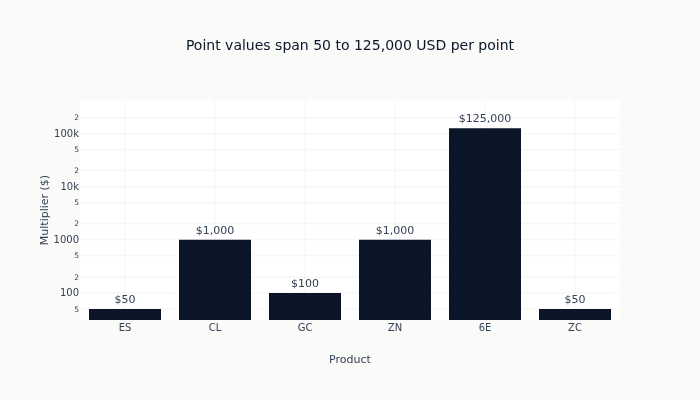

In [11]:
# Visualize multiplier range across products
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[DEMO_SPECS[p].symbol for p in PRODUCTS],
        y=[DEMO_SPECS[p].multiplier for p in PRODUCTS],
        text=[f"${DEMO_SPECS[p].multiplier:,.0f}" for p in PRODUCTS],
        textposition="outside",
        marker_color=COLORS["blue"],
    )
)
fig.update_layout(
    title=(
        f"Point values span {min(DEMO_SPECS[p].multiplier for p in PRODUCTS):,.0f} to "
        f"{max(DEMO_SPECS[p].multiplier for p in PRODUCTS):,.0f} USD per point"
    ),
    xaxis_title="Product",
    yaxis_title="Multiplier ($)",
    yaxis_type="log",
    height=400,
)
fig.show()

## 3. Prepare Data for DataFeed

The ml4t-backtest `DataFeed` requires: `timestamp` (Datetime), `symbol`,
`open`, `high`, `low`, `close`, `volume`. CME data keeps the canonical `product` identifier; the
feed-boundary alias to `symbol` is required by the generic engine. The timestamp is a session
label for a 4 PM CT close, not a midnight observation.

This example uses ratio-adjusted continuous OHLC for signals and engine marks, while the raw
front-contract close determines contract counts. That avoids splice jumps in momentum but does
not represent explicit rolls. The reported dollar P&L is a continuous-series research
approximation that excludes roll orders, roll costs, and contract-specific fill history.

In [12]:
feed_source = cme_data.with_columns(
    pl.col("session_date").cast(pl.Datetime).alias("timestamp"),
    pl.col("product").alias("symbol"),
)

prices_df = feed_source.select(
    "timestamp",
    "symbol",
    pl.col("adj_open").alias("open"),
    pl.col("adj_high").alias("high"),
    pl.col("adj_low").alias("low"),
    pl.col("adj_close").alias("close"),
    "volume",
).sort(["timestamp", "symbol"])

roll_transitions = (
    cme_data.sort(["product", "session_date"])
    .with_columns(
        (pl.col("cum_ratio") != pl.col("cum_ratio").shift(1).over("product"))
        .fill_null(False)
        .alias("roll_transition")
    )["roll_transition"]
    .sum()
)

print(f"DataFeed prices: {prices_df.shape}")
print(f"Schema: {dict(prices_df.schema)}")
print(f"Detected ratio-adjustment transitions in the demo panel: {roll_transitions:,}")

DataFeed prices: (9251, 7)
Schema: {'timestamp': Datetime(time_unit='us', time_zone=None), 'symbol': String, 'open': Float64, 'high': Float64, 'low': Float64, 'close': Float64, 'volume': UInt64}
Detected ratio-adjustment transitions in the demo panel: 218


Sample DataFeed bar (first timestamp, all assets):

In [13]:
first_ts = prices_df["timestamp"][0]
prices_df.filter(pl.col("timestamp") == first_ts)

timestamp,symbol,open,high,low,close,volume
datetime[μs],str,f64,f64,f64,f64,u64
2018-01-02 00:00:00,"""6E""",1.402626,1.410179,1.401057,1.407274,188647
2018-01-02 00:00:00,"""CL""",64.809484,65.390831,64.701827,64.9925,418784
2018-01-02 00:00:00,"""ES""",2571.233563,2591.176782,2570.512724,2589.254544,964658
2018-01-02 00:00:00,"""GC""",1761.90507,1782.287179,1760.960204,1780.532428,255702
2018-01-02 00:00:00,"""ZC""",412.912543,416.14531,412.030879,415.263647,124667
2018-01-02 00:00:00,"""ZN""",123.932095,123.947714,123.479161,123.635346,1021004


## 4. Momentum Signal

We compute a 63-session trailing return for each product. This signal drives
cross-sectional ranking in the strategy.

In [14]:
# Compute trailing momentum per product
momentum_df = feed_source.sort(["symbol", "timestamp"]).with_columns(
    (pl.col("adj_close") / pl.col("adj_close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
)

# The raw close enters only the contemporaneous notional-sizing denominator.
signals_df = momentum_df.select(["timestamp", "symbol", "raw_close", "momentum"])

valid_count = signals_df.filter(pl.col("momentum").is_not_null()).shape[0]
print(f"Signal rows: {len(signals_df):,} ({valid_count:,} with valid momentum)")

Signal rows: 9,251 (8,873 with valid momentum)


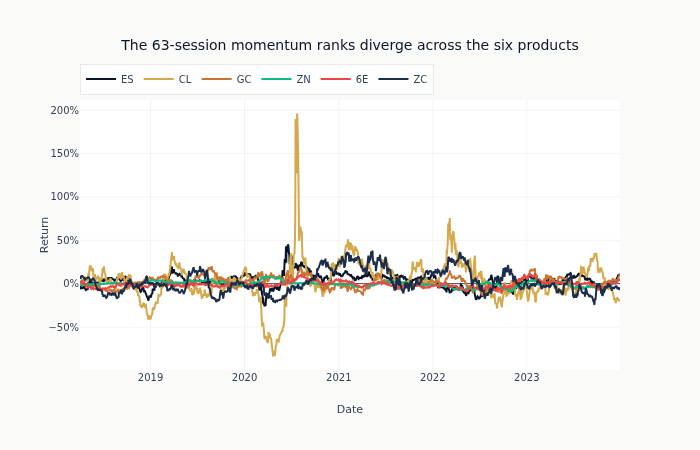

In [15]:
# Visualize momentum by product over time
fig = go.Figure()
for product in PRODUCTS:
    prod_data = momentum_df.filter((pl.col("symbol") == product) & pl.col("momentum").is_not_null())
    fig.add_trace(
        go.Scatter(
            x=prod_data["timestamp"].to_list(),
            y=prod_data["momentum"].to_list(),
            name=product,
            mode="lines",
            line={"color": COLOR_CYCLER[PRODUCTS.index(product)]},
        )
    )

fig.update_layout(
    title=f"The {LOOKBACK}-session momentum ranks diverge across the six products",
    xaxis_title="Date",
    yaxis_title="Return",
    yaxis_tickformat=".0%",
    height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

## 5. Futures Momentum Strategy

Cross-sectional momentum ranks products by recent performance. We go **long**
the top performers and **short** the bottom performers. This long-short
structure is natural for futures:

- **No stock-loan step**: Short futures require margin rather than borrowed shares
- **Symmetric P&L**: Long and short have identical cost structure
- **Explicit gross exposure**: Positive and negative notionals can be budgeted together

### Position Sizing for Futures

Each position targets equal notional exposure:

$$\text{contracts} = \left\lfloor \frac{\text{allocation}}{\text{price} \times \text{multiplier}} \right\rfloor$$

The integer floor keeps each selected product at or below its allocation. If one contract exceeds
that allocation, the target is not traded rather than being forced into an oversized position.

In [16]:
def compute_target_contracts(
    data,
    specs: dict[str, ContractSpec],
    long_n: int,
    short_n: int,
    capital_base: float,
) -> tuple[dict[str, int], int] | None:
    """Rank current signals and convert equal notionals to signed integer contracts."""
    momentum = {
        asset: value
        for asset, bar in data.items()
        if (value := bar.get("signals", {}).get("momentum")) is not None and np.isfinite(value)
    }
    if len(momentum) < long_n + short_n:
        return None

    ranked = sorted(momentum, key=momentum.get, reverse=True)
    directions = {asset: 1 for asset in ranked[:long_n]}
    directions.update({asset: -1 for asset in ranked[-short_n:]})
    allocation = capital_base / (long_n + short_n)
    targets = {}
    skipped = 0
    for asset, direction in directions.items():
        raw_close = data[asset].get("signals", {}).get("raw_close")
        if raw_close is None or not np.isfinite(raw_close) or raw_close <= 0:
            continue
        quantity = int(allocation / (raw_close * specs[asset].multiplier))
        if quantity == 0:
            skipped += 1
        else:
            targets[asset] = direction * quantity
    return targets, skipped

In [17]:
def submit_contract_deltas(target_quantities: dict[str, int], broker) -> None:
    """Submit signed order deltas from current to target contract quantities."""
    for asset in sorted(set(broker.positions) | set(target_quantities)):
        position = broker.get_position(asset)
        current_quantity = position.quantity if position is not None else 0.0
        delta = target_quantities.get(asset, 0.0) - current_quantity
        if abs(delta) < 1e-12:
            continue
        side = OrderSide.BUY if delta > 0 else OrderSide.SELL
        broker.submit_order(asset, abs(delta), side)

In [18]:
class FuturesMomentumStrategy(Strategy):
    """Cross-sectional momentum on futures with proper contract sizing.

    Rebalances every N bars: long top performers, short bottom performers.
    Position sizing uses notional value (price x multiplier) to ensure
    equal dollar exposure across products with different contract sizes.
    """

    def __init__(
        self,
        contract_specs: dict[str, ContractSpec],
        long_n: int = 2,
        short_n: int = 2,
        rebalance_every: int = 21,
    ):
        self.specs = contract_specs
        self.long_n = long_n
        self.short_n = short_n
        self.rebalance_every = rebalance_every
        self.bar_count = 0
        self.target_history = []
        self.zero_contract_targets = 0

    def on_data(self, timestamp, data, context, broker):
        self.bar_count += 1
        if self.bar_count % self.rebalance_every != 0:
            return
        current_equity = broker.get_account_value()
        if current_equity <= 0:
            return
        target_result = compute_target_contracts(
            data, self.specs, self.long_n, self.short_n, current_equity
        )
        if target_result is None:
            return
        target_quantities, skipped = target_result
        self.zero_contract_targets += skipped
        self.target_history.append((timestamp, dict(sorted(target_quantities.items()))))
        submit_contract_deltas(target_quantities, broker)

## 6. Configure and Run Backtest

The `BacktestConfig` controls all behavioral settings. For futures:

- `CommissionType.PER_CONTRACT` with `commission_per_share=2.00` models
  an illustrative **$2 per contract per fill side**, not a broker quote
- `allow_short_selling=True` enables short positions
- `allow_leverage=True` activates the per-product margin percentages in `ContractSpec`
- 5 bps percentage slippage is a simplifying common-unit assumption; a production futures
  simulator would use product-specific ticks, spread, liquidity, and roll costs

Momentum and the raw sizing price are observed at session close. `ExecutionMode.NEXT_BAR` holds
the submitted integer quantity fixed and fills it at the following session's adjusted open, so the
signal does not receive the return into its own fill.

`ContractSpec` is **product metadata** (static per instrument), not a behavioral
knob. Pass `contract_specs=` to the `Engine` constructor - the Engine threads
it through to the `Broker` automatically.

In [19]:
config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    # Illustrative per-contract commission
    commission_type=CommissionType.PER_CONTRACT,
    commission_per_share=2.00,
    commission_minimum=2.00,
    # Slippage: 5 bps of price
    slippage_type=SlippageType.PERCENTAGE,
    slippage_rate=0.0005,
    # Futures require short selling and leverage
    allow_short_selling=True,
    allow_leverage=True,
)

# Create DataFeed with prices and momentum signals
feed = DataFeed(prices_df=prices_df, signals_df=signals_df)

# Create strategy
strategy = FuturesMomentumStrategy(
    contract_specs=DEMO_SPECS,
    long_n=LONG_N,
    short_n=SHORT_N,
    rebalance_every=REBALANCE_EVERY,
)

# Create engine with contract specs - Engine threads them to the Broker
engine = Engine(feed=feed, strategy=strategy, config=config, contract_specs=DEMO_SPECS)

# Run backtest
result = engine.run()

print(f"Completed target rebalances: {len(strategy.target_history):,}")
print(f"Targets below one-contract granularity: {strategy.zero_contract_targets:,}")

Completed target rebalances: 69
Targets below one-contract granularity: 0


**Futures momentum backtest - with contract specs.**

In [20]:
pl.DataFrame(
    {
        "metric": [
            "Initial capital ($)",
            "Final value ($)",
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Total trades",
            "Win rate (%)",
        ],
        "value": [
            float(INITIAL_CASH),
            float(result.metrics["final_value"]),
            float(result.metrics["total_return_pct"]),
            float(result.metrics["sharpe"]),
            float(result.metrics["max_drawdown_pct"]),
            float(result.metrics["num_trades"]),
            float(result.metrics["win_rate"] * 100),
        ],
    }
)

metric,value
str,f64
"""Initial capital ($)""",1e7
"""Final value ($)""",9.8063e6
"""Total return (%)""",-1.937346
"""Sharpe ratio""",0.038977
"""Max drawdown (%)""",31.496977
"""Total trades""",99.0
"""Win rate (%)""",48.484848


In [21]:
display(
    Markdown(
        f"The six-product teaching run returns **{result.metrics['total_return_pct']:.2f}%** with "
        f"a **{result.metrics['sharpe']:.2f} Sharpe** and "
        f"**{result.metrics['max_drawdown_pct']:.2f}% maximum drawdown**. The result is descriptive "
        "and in-sample. It motivates volatility targeting and portfolio-level risk limits rather "
        "than supporting a performance claim."
    )
)

The six-product teaching run returns **-1.94%** with a **0.04 Sharpe** and **31.50% maximum drawdown**. The result is descriptive and in-sample. It motivates volatility targeting and portfolio-level risk limits rather than supporting a performance claim.

## 7. Analyze Trades

Verify that the broker applied the correct multiplier per product.
Each trade's P&L should reflect the contract multiplier.

In [22]:
trades_df = result.to_trades_dataframe()
closed_trades = trades_df.filter(pl.col("status") == "closed")

print(f"Total trades: {len(trades_df)} ({len(closed_trades)} closed)")

Total trades: 103 (99 closed)


Sample of closed trades with multiplier-correct P&L and cost decomposition:

In [23]:
closed_trades.select(
    [
        "symbol",
        "direction",
        "quantity",
        "entry_price",
        "exit_price",
        "pnl",
        "pnl_percent",
        "gross_pnl",
        "cost_drag",
        "bars_held",
    ]
).head(10)

symbol,direction,quantity,entry_price,exit_price,pnl,pnl_percent,gross_pnl,cost_drag,bars_held
str,str,f64,f64,f64,f64,f64,f64,f64,i32
"""ES""","""short""",-18.0,2538.186649,2585.611866,-42754.695766,-0.018685,-42682.695766,0.001041,21
"""GC""","""short""",-19.0,1738.622597,1673.609938,123448.052087,0.037393,123524.052087,0.001004,21
"""ZC""","""long""",125.0,450.692171,394.684893,-350545.488361,-0.124269,-350045.488361,0.000882,42
"""6E""","""short""",-17.0,1.393901,1.33958,115364.478324,0.038971,115432.478324,0.001003,63
"""CL""","""long""",36.0,74.079811,74.146343,2243.1523,0.000898,2395.1523,0.000804,126
"""ES""","""long""",17.0,2595.063423,2625.563164,25854.779721,0.011753,25924.779721,0.000777,84
"""GC""","""short""",-21.0,1628.600496,1634.616502,-12717.614294,-0.003694,-12633.614294,0.000782,63
"""ZC""","""short""",-145.0,393.459558,386.761854,47962.360822,0.017023,48558.360822,0.000747,84
"""ZC""","""long""",144.0,386.144,380.017159,-44689.252846,-0.015867,-44113.252846,0.000957,42


Trade summary by product (P&L, win rate):

In [24]:
trade_summary = (
    closed_trades.group_by("symbol")
    .agg(
        pl.len().alias("trades"),
        pl.col("pnl").sum().alias("total_pnl"),
        pl.col("pnl").mean().alias("avg_pnl"),
        (pl.col("pnl") > 0).mean().alias("win_rate"),
    )
    .sort("total_pnl", descending=True)
)
trade_summary

symbol,trades,total_pnl,avg_pnl,win_rate
str,u32,f64,f64,f64
"""GC""",18,629512.340078,34972.907782,0.666667
"""6E""",9,510248.336061,56694.259562,0.555556
"""ZN""",19,-22870.960448,-1203.73476,0.526316
"""CL""",19,-776879.292746,-40888.383829,0.473684
"""ES""",16,-1.0848e6,-67799.118469,0.375
"""ZC""",18,-1.2492e6,-69402.431184,0.333333


In [25]:
best_product = trade_summary.row(0, named=True)
worst_product = trade_summary.row(-1, named=True)
display(
    Markdown(
        f"P&L is concentrated: **{best_product['symbol']}** contributes "
        f"**{format_usd(best_product['total_pnl'])}**, while "
        f"**{worst_product['symbol']}** contributes "
        f"**{format_usd(worst_product['total_pnl'])}**. This small-universe result motivates the broader "
        "universe comparison, but does not establish diversification."
    )
)

P&L is concentrated: **GC** contributes **$629,512**, while **ZC** contributes **-$1,249,244**. This small-universe result motivates the broader universe comparison, but does not establish diversification.

## 8. Without Multipliers - The Error

A controlled counterfactual replaces every broker multiplier with 1.0 while replaying the exact
target-contract schedule produced by the multiplier-aware run. This prevents the counterfactual's
different equity path from feeding back into sizing. The counterfactual changes the engine's
position valuation, margin basis, and point-to-dollar P&L conversion, not the intended orders.

In [26]:
UNIT_MULTIPLIER_SPECS = {
    product: ContractSpec(
        symbol=product,
        asset_class=AssetClass.FUTURE,
        multiplier=1.0,
        tick_size=spec.tick_size,
        margin_pct=spec.margin_pct,
    )
    for product, spec in DEMO_SPECS.items()
}


class TargetScheduleStrategy(Strategy):
    """Replay a precomputed signed-contract schedule without recalculating size."""

    def __init__(self, schedule):
        self.schedule = schedule
        self.target_history = []

    def on_data(self, timestamp, data, context, broker):
        if timestamp not in self.schedule:
            return
        target_quantities = self.schedule[timestamp]
        self.target_history.append((timestamp, target_quantities))
        submit_contract_deltas(target_quantities, broker)

In [27]:
target_schedule = dict(strategy.target_history)
feed_nomult = DataFeed(prices_df=prices_df, signals_df=signals_df)
strategy_nomult = TargetScheduleStrategy(target_schedule)
engine_nomult = Engine(
    feed=feed_nomult,
    strategy=strategy_nomult,
    config=config,
    contract_specs=UNIT_MULTIPLIER_SPECS,
)
result_nomult = engine_nomult.run()

assert strategy.target_history == strategy_nomult.target_history

In [28]:
pl.DataFrame(
    {
        "metric": ["Final value ($)", "Total return (%)", "Max drawdown (%)"],
        "with_specs": [
            result.metrics["final_value"],
            result.metrics["total_return_pct"],
            result.metrics["max_drawdown_pct"],
        ],
        "without_multipliers": [
            result_nomult.metrics["final_value"],
            result_nomult.metrics["total_return_pct"],
            result_nomult.metrics["max_drawdown_pct"],
        ],
    }
)

metric,with_specs,without_multipliers
str,f64,f64
"""Final value ($)""",9.8063e6,9.9583e6
"""Total return (%)""",-1.937346,-0.417223
"""Max drawdown (%)""",31.496977,0.731172


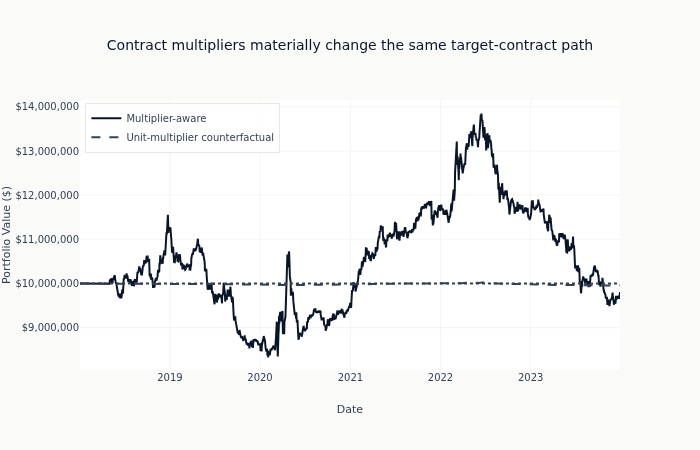

In [29]:
# Overlay equity curves
fig = go.Figure()
ec_with = result.equity
ec_without = result_nomult.equity

fig.add_trace(
    go.Scatter(
        x=ec_with.timestamps,
        y=ec_with.values,
        name="Multiplier-aware",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=ec_without.timestamps,
        y=ec_without.values,
        name="Unit-multiplier counterfactual",
        line=dict(color=COLORS["neutral"], width=2, dash="dash"),
    )
)
fig.add_hline(y=INITIAL_CASH, line_dash="dot", line_color=COLORS["neutral"])

fig.update_layout(
    title="Contract multipliers materially change the same target-contract path",
    xaxis_title="Date",
    yaxis_title="Portfolio Value ($)",
    yaxis_tickformat="$,.0f",
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

In [30]:
display(
    Markdown(
        f"With the same intended contract targets, the multiplier-aware run returns "
        f"**{result.metrics['total_return_pct']:.2f}%**, versus "
        f"**{result_nomult.metrics['total_return_pct']:.2f}%** under unit multipliers. The gap "
        "shows why point values are part of the accounting contract; neither curve should be read "
        "as a deployable rolled-futures performance estimate."
    )
)

With the same intended contract targets, the multiplier-aware run returns **-1.94%**, versus **-0.42%** under unit multipliers. The gap shows why point values are part of the accounting contract; neither curve should be read as a deployable rolled-futures performance estimate.

## 9. Sector Attribution

Futures span multiple asset classes. We map each product to its sector and compute P&L
contribution without assuming those sectors are uncorrelated.

In [31]:
SECTOR_MAP = {
    "ES": "Equity Index",
    "CL": "Energy",
    "GC": "Metals",
    "ZN": "Rates",
    "6E": "FX",
    "ZC": "Agriculture",
}

sector_pnl = (
    closed_trades.with_columns(
        pl.col("symbol").replace_strict(SECTOR_MAP, default="Other").alias("sector")
    )
    .group_by("sector")
    .agg(
        pl.col("pnl").sum().alias("total_pnl"),
        pl.len().alias("trades"),
        (pl.col("pnl") > 0).mean().alias("win_rate"),
    )
    .sort("total_pnl", descending=True)
)
sector_pnl

sector,total_pnl,trades,win_rate
str,f64,u32,f64
"""Metals""",629512.340078,18,0.666667
"""FX""",510248.336061,9,0.555556
"""Rates""",-22870.960448,19,0.526316
"""Energy""",-776879.292746,19,0.473684
"""Equity Index""",-1.0848e6,16,0.375
"""Agriculture""",-1.2492e6,18,0.333333


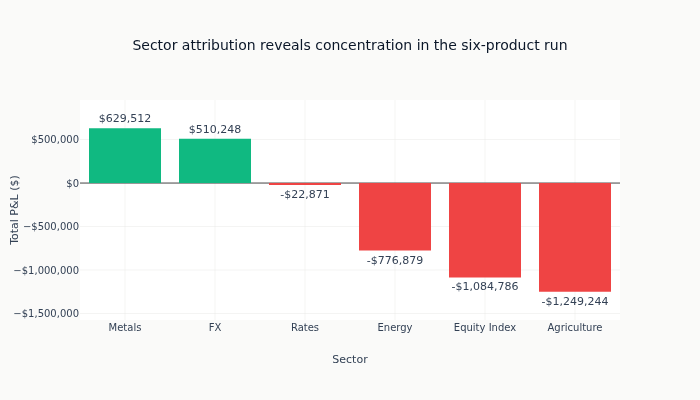

In [32]:
# Visualize sector P&L
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=sector_pnl["sector"].to_list(),
        y=sector_pnl["total_pnl"].to_list(),
        marker_color=[
            COLORS["positive"] if pnl > 0 else COLORS["negative"]
            for pnl in sector_pnl["total_pnl"].to_list()
        ],
        text=[format_usd(p) for p in sector_pnl["total_pnl"].to_list()],
        textposition="outside",
    )
)
fig.update_layout(
    title="Sector attribution reveals concentration in the six-product run",
    xaxis_title="Sector",
    yaxis_title="Total P&L ($)",
    yaxis_tickformat="$,.0f",
    height=400,
)
fig.show()

In [33]:
best_sector = sector_pnl.row(0, named=True)
worst_sector = sector_pnl.row(-1, named=True)
display(
    Markdown(
        f"With one product per sector, sector and product attribution are identical. "
        f"**{best_sector['sector']}** contributes the most P&L "
        f"(**{format_usd(best_sector['total_pnl'])}**), while "
        f"**{worst_sector['sector']}** contributes the least "
        f"(**{format_usd(worst_sector['total_pnl'])}**). The wider universe tests whether "
        "adding eligible products changes this concentration."
    )
)

With one product per sector, sector and product attribution are identical. **Metals** contributes the most P&L (**$629,512**), while **Agriculture** contributes the least (**-$1,249,244**). The wider universe tests whether adding eligible products changes this concentration.

## 10. Full Available Universe

Scale from six demo products to every product present in both the current CME data snapshot and
the current specifications file. This is a fixed, current teaching universe, not historical
membership or a survivorship-free universe estimate. Product eligibility on each bar still
depends on data availability at that timestamp.

In [34]:
print(f"Loaded {len(FULL_SPECS)} product specifications from YAML")

Loaded 36 product specifications from YAML


Cross-check the instantiated point values against the independent tick-value identity in the raw
YAML: point value equals tick value divided by tick size.

In [35]:
with SPECS_PATH.open() as file:
    raw_specification = yaml.safe_load(file)["products"]

verify_rows = []
for product in PRODUCTS:
    engine_multiplier = DEMO_SPECS[product].multiplier
    tick_identity = (
        raw_specification[product]["tick_value"] / raw_specification[product]["tick_size"]
    )
    verify_rows.append(
        {
            "product": product,
            "engine_multiplier": float(engine_multiplier),
            "tick_value_over_tick_size": float(tick_identity),
            "match": abs(engine_multiplier - tick_identity) < 1e-12,
        }
    )
multiplier_check = pl.DataFrame(verify_rows)
assert multiplier_check["match"].all()
multiplier_check

product,engine_multiplier,tick_value_over_tick_size,match
str,f64,f64,bool
"""ES""",50.0,50.0,true
"""CL""",1000.0,1000.0,true
"""GC""",100.0,100.0,true
"""ZN""",1000.0,1000.0,true
"""6E""",125000.0,125000.0,true
"""ZC""",50.0,50.0,true


In [36]:
if RUN_FULL_UNIVERSE:
    cme_all = load_cme_futures(tenors=[0], start_date=START_DATE, end_date=END_DATE)
    available_products = set(cme_all["product"].unique().to_list())
    universe = sorted(available_products & set(FULL_SPECS.keys()))

    print(f"\nAvailable in data: {len(available_products)} products")
    print(f"Have specs for:    {len(FULL_SPECS)} products")
    print(f"Universe:          {len(universe)} products")
    print(f"Products: {universe}")

    cme_all = cme_all.filter(pl.col("product").is_in(universe))


Available in data: 30 products
Have specs for:    36 products
Universe:          30 products
Products: ['6A', '6B', '6C', '6E', '6J', '6S', 'CL', 'ES', 'GC', 'GF', 'HE', 'HG', 'HO', 'LE', 'NG', 'NQ', 'PL', 'RB', 'RTY', 'SI', 'YM', 'ZB', 'ZC', 'ZF', 'ZL', 'ZM', 'ZN', 'ZS', 'ZT', 'ZW']


In [37]:
if RUN_FULL_UNIVERSE:
    feed_full_source = cme_all.with_columns(
        pl.col("session_date").cast(pl.Datetime).alias("timestamp"),
        pl.col("product").alias("symbol"),
    )

    prices_full = feed_full_source.select(
        "timestamp",
        "symbol",
        pl.col("adj_open").alias("open"),
        pl.col("adj_high").alias("high"),
        pl.col("adj_low").alias("low"),
        pl.col("adj_close").alias("close"),
        "volume",
    ).sort(["timestamp", "symbol"])

    signals_full = (
        feed_full_source.sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col("adj_close") / pl.col("adj_close").shift(LOOKBACK).over("symbol") - 1).alias(
                "momentum"
            )
        )
        .select(["timestamp", "symbol", "raw_close", "momentum"])
    )

In [38]:
if RUN_FULL_UNIVERSE:
    universe_specs = {p: FULL_SPECS[p] for p in universe}

    feed_full = DataFeed(prices_df=prices_full, signals_df=signals_full)
    strategy_full = FuturesMomentumStrategy(
        contract_specs=universe_specs,
        long_n=6,
        short_n=6,
        rebalance_every=REBALANCE_EVERY,
    )
    engine_full = Engine(
        feed=feed_full, strategy=strategy_full, config=config, contract_specs=universe_specs
    )

    result_full = engine_full.run()
    print(f"Full-universe target rebalances: {len(strategy_full.target_history):,}")
    print(f"Full-universe targets below one contract: {strategy_full.zero_contract_targets:,}")

Full-universe target rebalances: 70
Full-universe targets below one contract: 0


Six-product baseline vs full CME universe - same momentum rule, same costs:

In [39]:
if RUN_FULL_UNIVERSE:
    comparison = pl.DataFrame(
        {
            "metric": [
                "Products",
                "Final value ($)",
                "Sharpe ratio",
                "Max drawdown (%)",
                "Total trades",
            ],
            "six_products": [
                float(len(PRODUCTS)),
                float(result.metrics["final_value"]),
                float(result.metrics["sharpe"]),
                float(result.metrics["max_drawdown_pct"]),
                float(result.metrics["num_trades"]),
            ],
            "full_universe": [
                float(len(universe)),
                float(result_full.metrics["final_value"]),
                float(result_full.metrics["sharpe"]),
                float(result_full.metrics["max_drawdown_pct"]),
                float(result_full.metrics["num_trades"]),
            ],
        }
    )
else:
    comparison = pl.DataFrame({"note": ["Skipped full-universe scaling (RUN_FULL_UNIVERSE=False)"]})
comparison

metric,six_products,full_universe
str,f64,f64
"""Products""",6.0,30.0
"""Final value ($)""",9.8063e6,5.7502e6
"""Sharpe ratio""",0.038977,-0.167012
"""Max drawdown (%)""",31.496977,72.76314
"""Total trades""",99.0,380.0


In [40]:
if RUN_FULL_UNIVERSE:
    sharpe_relation = (
        "higher" if result_full.metrics["sharpe"] > result.metrics["sharpe"] else "lower"
    )
    drawdown_relation = (
        "higher"
        if result_full.metrics["max_drawdown_pct"] > result.metrics["max_drawdown_pct"]
        else "lower"
    )
    display(
        Markdown(
            f"Expanding from **{len(PRODUCTS)} to {len(universe)} products** changes closed trades "
            f"from **{result.metrics['num_trades']:.0f} to {result_full.metrics['num_trades']:.0f}**. "
            f"The broader run has a **{sharpe_relation} Sharpe** "
            f"(**{result_full.metrics['sharpe']:.2f}** versus **{result.metrics['sharpe']:.2f}**) "
            f"and **{drawdown_relation} maximum drawdown** "
            f"(**{result_full.metrics['max_drawdown_pct']:.2f}%** versus "
            f"**{result.metrics['max_drawdown_pct']:.2f}%**). Universe breadth alone does not "
            "establish diversification; Ch17-19 add risk-targeted sizing and sector constraints."
        )
    )

Expanding from **6 to 30 products** changes closed trades from **99 to 380**. The broader run has a **lower Sharpe** (**-0.17** versus **0.04**) and **higher maximum drawdown** (**72.76%** versus **31.50%**). Universe breadth alone does not establish diversification; Ch17-19 add risk-targeted sizing and sector constraints.

## 11. Cost Analysis - Per-Contract vs Percentage

A single percentage-of-notional commission cannot reproduce a constant per-contract fee across
products with different unit notionals. We compare the configured illustrative $2-per-contract
per-side fee with current notionals; this is not a broker quote.

Notional value per contract by product, and a flat \$2 commission expressed as
a percentage of notional. The cost percentage varies materially across
products because their multipliers and prices differ; the printed min/max
below quantifies the spread for the six demo contracts.

In [41]:
cost_rows = []
for product in PRODUCTS:
    spec = DEMO_SPECS[product]
    price = float(cme_data.filter(pl.col("product") == product)["raw_close"][-1])
    notional = price * spec.multiplier
    cost_rows.append(
        {
            "product": product,
            "price": price,
            "multiplier": float(spec.multiplier),
            "notional_usd": notional,
            "two_dollar_pct_of_notional": 2.0 / notional * 100,
        }
    )
cost_table = pl.DataFrame(cost_rows)
_cost_min = cost_table["two_dollar_pct_of_notional"].min()
_cost_max = cost_table["two_dollar_pct_of_notional"].max()
print(
    f"$2/contract cost as % of notional: min {_cost_min:.4f}%, "
    f"max {_cost_max:.4f}% (ratio {_cost_max / _cost_min:.1f}×)"
)
cost_table

$2/contract cost as % of notional: min 0.0008%, max 0.0085% (ratio 10.2×)


product,price,multiplier,notional_usd,two_dollar_pct_of_notional
str,f64,f64,f64,f64
"""ES""",4812.75,50.0,240637.5,0.000831
"""CL""",71.33,1000.0,71330.0,0.002804
"""GC""",2071.8,100.0,207180.0,0.000965
"""ZN""",112.6875,1000.0,112687.5,0.001775
"""6E""",1.10705,125000.0,138381.25,0.001445
"""ZC""",470.75,50.0,23537.5,0.008497


In [42]:
smallest_notional = cost_table.sort("notional_usd").row(0, named=True)
largest_notional = cost_table.sort("notional_usd").row(-1, named=True)
display(
    Markdown(
        f"The current demo notionals range from **${smallest_notional['notional_usd']:,.0f}** "
        f"({smallest_notional['product']}) to **${largest_notional['notional_usd']:,.0f}** "
        f"({largest_notional['product']}), a **{largest_notional['notional_usd'] / smallest_notional['notional_usd']:.1f}x** "
        f"spread. A flat $2 fee therefore ranges from **{_cost_min:.4f}%** to "
        f"**{_cost_max:.4f}%** of notional. Per-contract and percentage cost models encode "
        "different assumptions rather than interchangeable units."
    )
)

The current demo notionals range from **$23,538** (ZC) to **$240,638** (ES), a **10.2x** spread. A flat $2 fee therefore ranges from **0.0008%** to **0.0085%** of notional. Per-contract and percentage cost models encode different assumptions rather than interchangeable units.

## Key Takeaways

1. **Contract metadata is part of accounting.** Point-value multipliers convert price moves to
   dollars, while tick size and margin fields define execution and admissibility.

2. **Position sizing uses notional value**: $q = \lfloor \text{alloc} / (\text{price} \times \text{multiplier}) \rfloor$.
   This ensures equal dollar exposure across products with different multipliers.

3. **Long-short does not require a stock loan**, but both legs require margin. This notebook does
   not model financing, portfolio-margin offsets, or time-varying margin schedules.

4. **Cost units must match the protocol.** The example charges an illustrative $2 per contract
   per side and 5 bps slippage; production estimates should be product- and time-specific.

5. **Sector attribution exposes concentration**, not diversification by itself. Section 10
   computes the broader-universe comparison from the current run; Ch17-19 test risk-targeted
   sizing and sector constraints.

6. **Continuous-series output is an approximation.** Ratio-adjusted prices support stable signals,
   but this notebook does not execute individual contract rolls or charge roll-specific costs.

## Next Steps

- **CME case study**: `case_studies/cme_futures/strategy/backtest.py`
- **Ch17**: Portfolio construction with margin-based position sizing
- **Ch18**: Transaction cost decomposition for futures

## Cross-References

- **Ch2 NB 05**: Session boundary aggregation (4 PM CT → daily bars)
- **Ch2 NB 06**: Continuous contract construction (Panama/ratio adjustment)
- `ml4t.backtest.types.ContractSpec`: Full API reference